In [127]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

from data.data_preprocessing import load_and_split_data

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Import model functions
from data.models.bayesian_ridge import bayesian_ridge_model, bayesian_ridge_tuned
from data.models.svr_model import svr_model, svr_tuned
from data.models.random_forest import random_forest_model, random_forest_tuned
from data.models.gradient_boosting import gradient_boosting_model, gradient_boosting_tuned
from data.models.mlp_regressor_model import mlp_regressor_model, mlp_regressor_tuned
from data.models.xgboost_model import xgboost_model, xgboost_tuned
from data.models.stacking_model import stacking_model

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Load and split data once
X_train, X_test, y_train, y_test, data = load_and_split_data()

In [3]:
# Check the data
print(f'Dataset shape: {data.shape}')
data.head()

Dataset shape: (355, 8)


,A,B,C,D,E,F,G,AOR
0,0.2,0.00005,0.4,0.28,4.000000e-07,0.3,0.6,40.250
1,0.3,0.00005,0.4,0.28,4.000000e-07,0.3,0.6,42.305
2,0.4,0.00005,0.4,0.28,4.000000e-07,0.3,0.6,43.680
3,0.5,0.00005,0.4,0.28,4.000000e-07,0.3,0.6,43.605
4,0.6,0.00005,0.4,0.28,4.000000e-07,0.3,0.6,43.215


In [4]:
# Statistical summary
data.describe()

,A,B,C,D,E,F,G,AOR
count,355.000000,355.000000,355.000000,355.000000,3.550000e+02,355.000000,355.000000,355.000000
mean,0.453400,0.000030,0.405707,0.343448,2.197324e-07,0.365915,0.517538,36.687352
std,0.189653,0.000025,0.190959,0.124833,1.405692e-07,0.132315,0.162453,5.985885
min,0.100000,0.000002,0.100000,0.100000,1.000000e-08,0.100000,0.100000,13.065000
25%,0.300000,0.000008,0.300000,0.280000,6.000000e-08,0.300000,0.365000,32.928750
50%,0.500000,0.000010,0.400000,0.300000,2.000000e-07,0.300000,0.600000,37.145000
75%,0.600000,0.000050,0.400000,0.400000,3.000000e-07,0.400000,0.600000,41.661250
max,0.900000,0.000100,0.900000,0.920000,8.000000e-07,0.900000,0.900000,63.670000


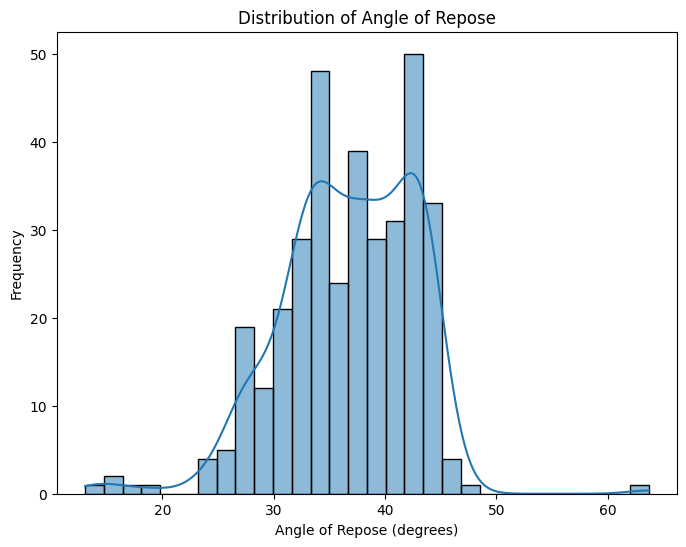

In [5]:
# Distribution of AOR
plt.figure(figsize=(8, 6))
sns.histplot(data['AOR'], kde=True, bins=30)
plt.title('Distribution of Angle of Repose')
plt.xlabel('Angle of Repose (degrees)')
plt.ylabel('Frequency')
plt.show()

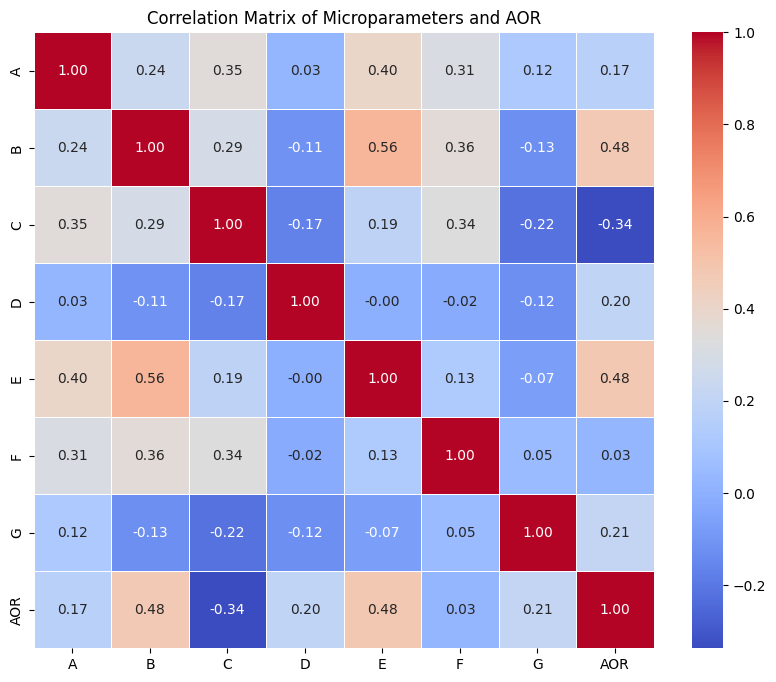

Correlations with AOR:
 AOR    1.000000
E      0.482541
B      0.475126
G      0.212471
D      0.197565
A      0.166894
F      0.025573
C     -0.337008
Name: AOR, dtype: float64


In [6]:
# Compute the correlation matrix
corr_matrix = data.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Microparameters and AOR")
plt.show()

# Focus on AOR correlations
print("Correlations with AOR:\n", corr_matrix["AOR"].sort_values(ascending=False))

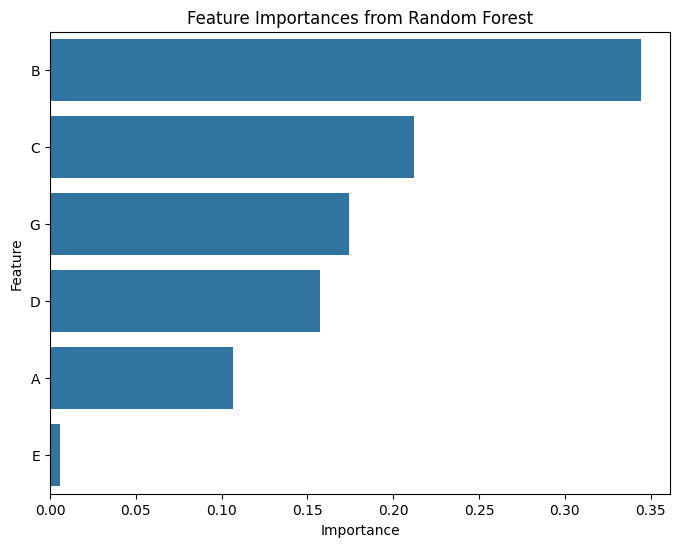

In [7]:
X = data.drop('AOR', axis=1).drop('F', axis=1)
y = data['AOR']

# Initialize the model
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf.fit(X, y)

# Get feature importances
importances = rf.feature_importances_
feature_names = X.columns
feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importances.sort_values(by='Importance', ascending=False, inplace=True)

# Plot feature importances
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title('Feature Importances from Random Forest')
plt.show()

In [21]:
# Dictionary to store results
results = {}

# Bayesian Ridge Regression
model, y_pred, mse, mae, r2 = bayesian_ridge_model(X_train, X_test, y_train, y_test)
results['Bayesian Ridge'] = {'model': model, 'MSE': mse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

model, y_pred, mse, mae, r2 = bayesian_ridge_tuned(X_train, X_test, y_train, y_test)
results['Bayesian Ridge Tuned'] = {'model': model, 'MSE': mse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

# Support Vector Regression
model, y_pred, mse, mae, r2 = svr_model(X_train, X_test, y_train, y_test)
results['SVR'] = {'model': model, 'MSE': mse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

model, y_pred, mse, mae, r2 = svr_tuned(X_train, X_test, y_train, y_test)
results['SVR Tuned'] = {'model': model, 'MSE': mse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

# Random Forest Regression
model, y_pred, mse, mae, r2 = random_forest_model(X_train, X_test, y_train, y_test)
results['Random Forest'] = {'model': model, 'MSE': mse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

model, y_pred, mse, mae, r2 = random_forest_tuned(X_train, X_test, y_train, y_test)
results['Random Forest Tuned'] = {'model': model, 'MSE': mse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

# Gradient Boosting Regression
model, y_pred, mse, mae, r2 = gradient_boosting_model(X_train, X_test, y_train, y_test)
results['Gradient Boosting'] = {'model': model, 'MSE': mse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

model, y_pred, mse, mae, r2 = gradient_boosting_tuned(X_train, X_test, y_train, y_test)
results['Gradient Boosting Tuned'] = {'model': model, 'MSE': mse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

# MLP Regression
model, y_pred, mse, mae, r2 = mlp_regressor_model(X_train, X_test, y_train, y_test)
results['MLP Regression'] = {'model': model, 'MSE': mse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

model, y_pred, mse, mae, r2 = mlp_regressor_tuned(X_train, X_test, y_train, y_test)
results['MLP Regression Tuned'] = {'model': model, 'MSE': mse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

# XGBoost Regression
model, y_pred, mse, mae, r2 = xgboost_model(X_train, X_test, y_train, y_test)
results['XGBoost'] = {'model': model, 'MSE': mse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

model, y_pred, mse, mae, r2 = xgboost_tuned(X_train, X_test, y_train, y_test)
results['XGBoost Tuned'] = {'model': model, 'MSE': mse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

# Stacking Regressor
model, y_pred, mse, mae, r2 = stacking_model(X_train, X_test, y_train, y_test)
results['Stacking Regressor'] = {'model': model, 'MSE': mse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

# Convert results to DataFrame
metrics_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})

Bayesian Ridge Regression
MSE: 6.8163
MAE: 1.8847
R2 Score: 0.7580
Best parameters for Bayesian Ridge: {'alpha_1': 0.0001, 'alpha_2': 1e-06, 'alpha_init': 1.9, 'lambda_1': 1e-06, 'lambda_2': 1e-06, 'lambda_init': 1e-09, 'n_iter': 300}
Best MSE: 17.1679
MSE: 6.8163
MAE: 1.8847
R2 Score: 0.7580
Support Vector Regression
MSE: 4.5010
MAE: 1.4632
R2 Score: 0.8402
Best parameters for SVR: {'C': 100.0, 'gamma': 1.0, 'kernel': 'rbf'}
Best MSE: 10.2448
MSE: 2.1158
MAE: 1.0690
R2 Score: 0.9249
Random Forest Regression
MSE: 1.8553
MAE: 1.0226
R2 Score: 0.9341
Best parameters for Random Forest: {'bootstrap': True, 'max_depth': 25, 'max_features': 0.75, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 10}
Best MSE: 8.7851
MSE: 3.3530
MAE: 1.2933
R2 Score: 0.8810
Gradient Boosting Regression
MSE: 1.9905
MAE: 1.0396
R2 Score: 0.9293
Best parameters for Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best MSE: 10.0114
MSE: 2.1060
MAE: 0.9724
R2 Score: 0.925

C:\Users\sukap\anaconda3\envs\cv3dst\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MSE: 8.8284
MAE: 2.2596
R2 Score: 0.6866


C:\Users\sukap\anaconda3\envs\cv3dst\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Best parameters for MLP: {'activation': 'relu', 'hidden_layer_sizes': (50, 50), 'learning_rate_init': 0.001}
Best MSE: 14.6606


C:\Users\sukap\anaconda3\envs\cv3dst\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MSE: 4.0320
MAE: 1.3913
R2 Score: 0.8569
XGBoost Regression
MSE: 7.5931
MAE: 1.6312
R2 Score: 0.7305
Tuned XGBoost Regression
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}
MSE: 1.9538
MAE: 0.9720
R2 Score: 0.9306
Stacking Regressor
MSE: 1.7581
MAE: 0.9907
R2 Score: 0.9376
Percentage Deviation: 2.65%


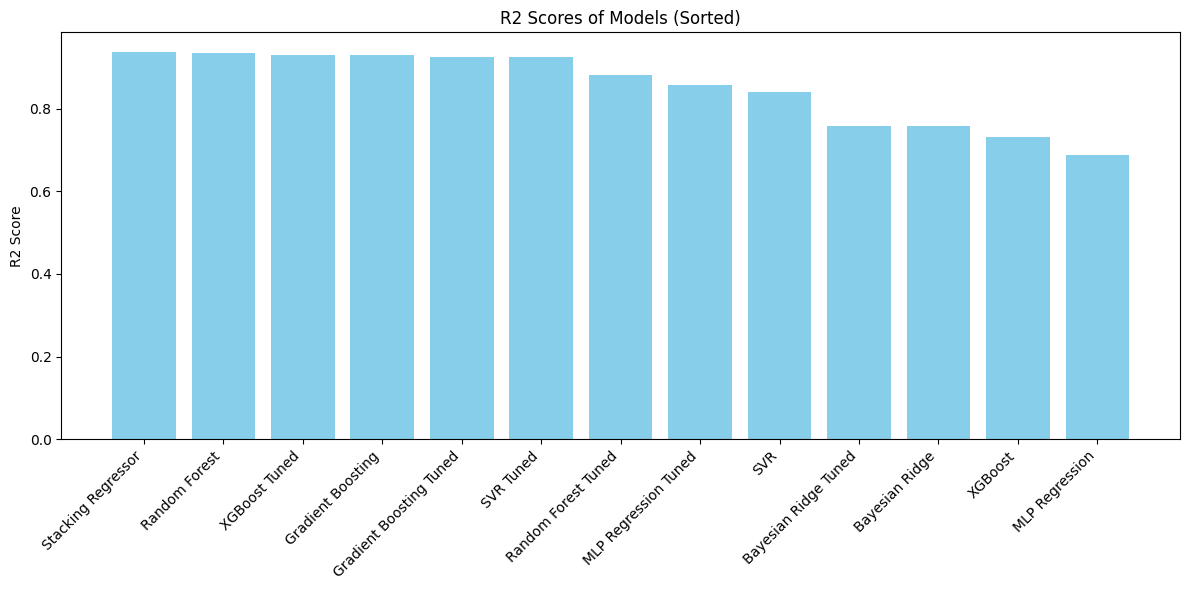

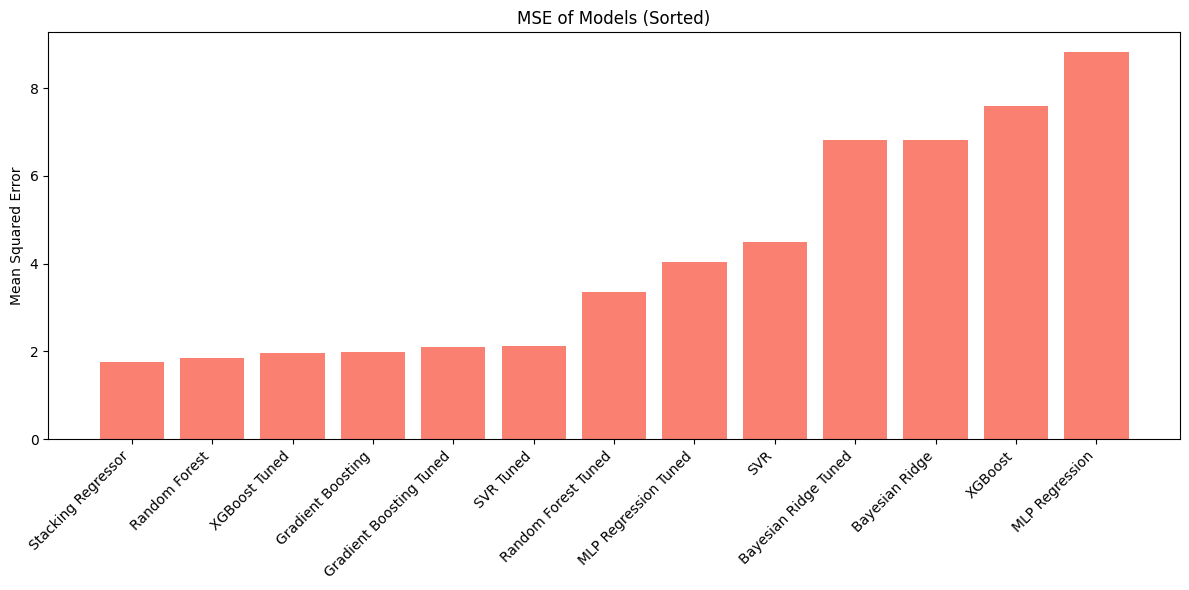

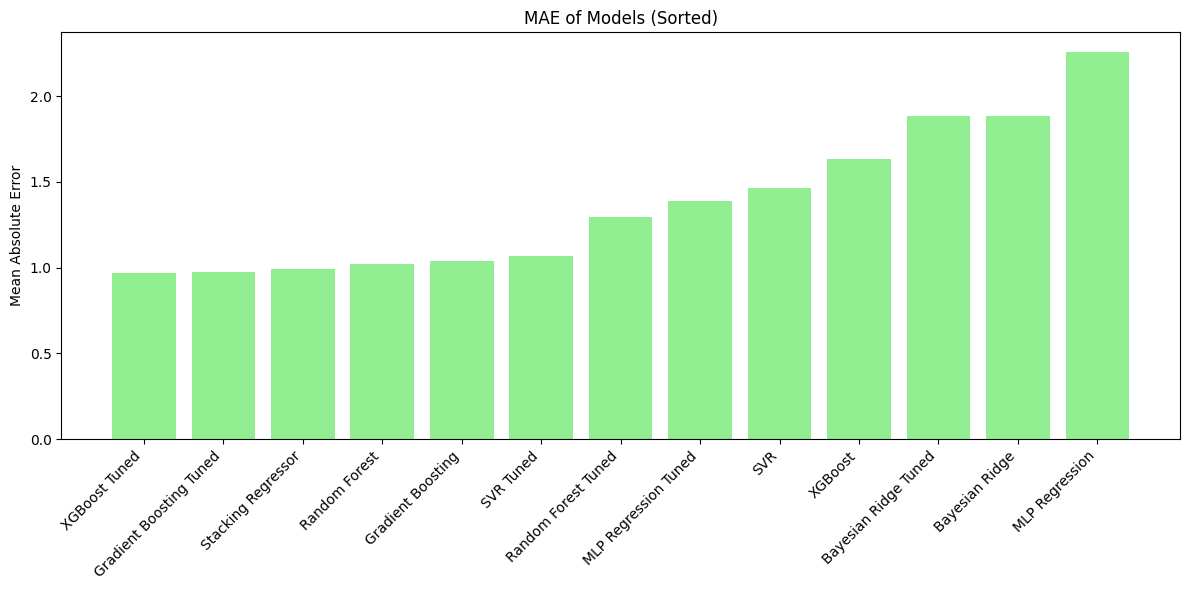

In [15]:
# # Plot R2 Scores
# plt.figure(figsize=(12, 6))
# plt.bar(metrics_df['Model'], metrics_df['R2'], color='skyblue')
# plt.xticks(rotation=45, ha='right')
# plt.ylabel('R2 Score')
# plt.title('R2 Scores of Models')
# plt.tight_layout()
# plt.show()

# # Plot MSE Comparison
# plt.figure(figsize=(12, 6))
# plt.bar(metrics_df['Model'], metrics_df['MSE'], color='salmon')
# plt.xticks(rotation=45, ha='right')
# plt.ylabel('Mean Squared Error')
# plt.title('MSE of Models')
# plt.tight_layout()
# plt.show()

# # Plot MAE Comparison
# plt.figure(figsize=(12, 6))
# plt.bar(metrics_df['Model'], metrics_df['MAE'], color='lightgreen')
# plt.xticks(rotation=45, ha='right')
# plt.ylabel('Mean Absolute Error')
# plt.title('MAE of Models')
# plt.tight_layout()
# plt.show()


# Plot R2 Scores (sorted by R2)
metrics_df_sorted_r2 = metrics_df.sort_values(by='R2', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(metrics_df_sorted_r2['Model'], metrics_df_sorted_r2['R2'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('R2 Score')
plt.title('R2 Scores of Models (Sorted)')
plt.tight_layout()
plt.show()

# Plot MSE Comparison (sorted by MSE)
metrics_df_sorted_mse = metrics_df.sort_values(by='MSE', ascending=True)  # Lower MSE is better, so ascending

plt.figure(figsize=(12, 6))
plt.bar(metrics_df_sorted_mse['Model'], metrics_df_sorted_mse['MSE'], color='salmon')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean Squared Error')
plt.title('MSE of Models (Sorted)')
plt.tight_layout()
plt.show()

# Plot MAE Comparison (sorted by MAE)
metrics_df_sorted_mae = metrics_df.sort_values(by='MAE', ascending=True)  # Lower MAE is better, so ascending

plt.figure(figsize=(12, 6))
plt.bar(metrics_df_sorted_mae['Model'], metrics_df_sorted_mae['MAE'], color='lightgreen')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean Absolute Error')
plt.title('MAE of Models (Sorted)')
plt.tight_layout()
plt.show()

               Model  MSE Improvement (%)  MAE Improvement (%)  \
0     Bayesian Ridge         2.144092e-07         2.505766e-07   
1                SVR         5.299250e+01         2.694304e+01   
2      Random Forest        -8.072723e+01        -2.646694e+01   
3  Gradient Boosting        -5.799835e+00         6.461851e+00   
4     MLP Regression         5.432983e+01         3.842653e+01   
5            XGBoost         7.426804e+01         4.041547e+01   

   R2 Improvement (%)  
0        6.844025e-08  
1        1.007712e+01  
2       -5.691530e+00  
3       -4.409825e-01  
4        2.479829e+01  
5        2.740514e+01  


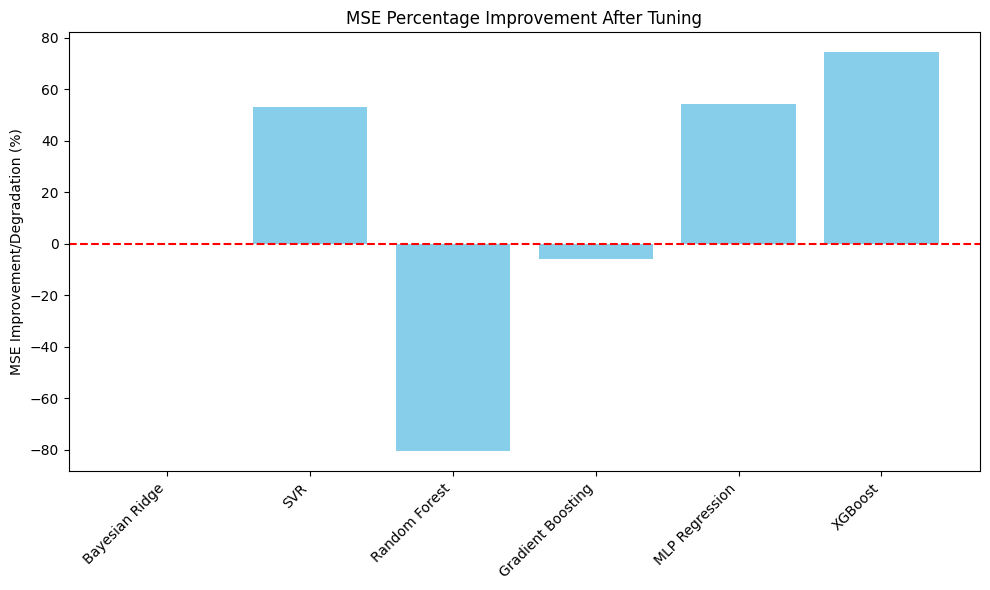

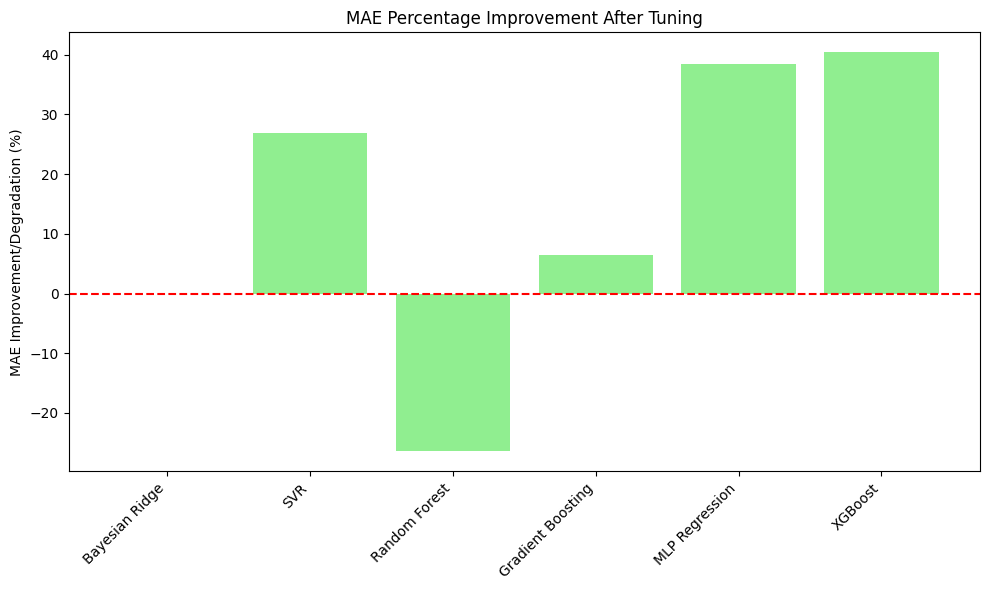

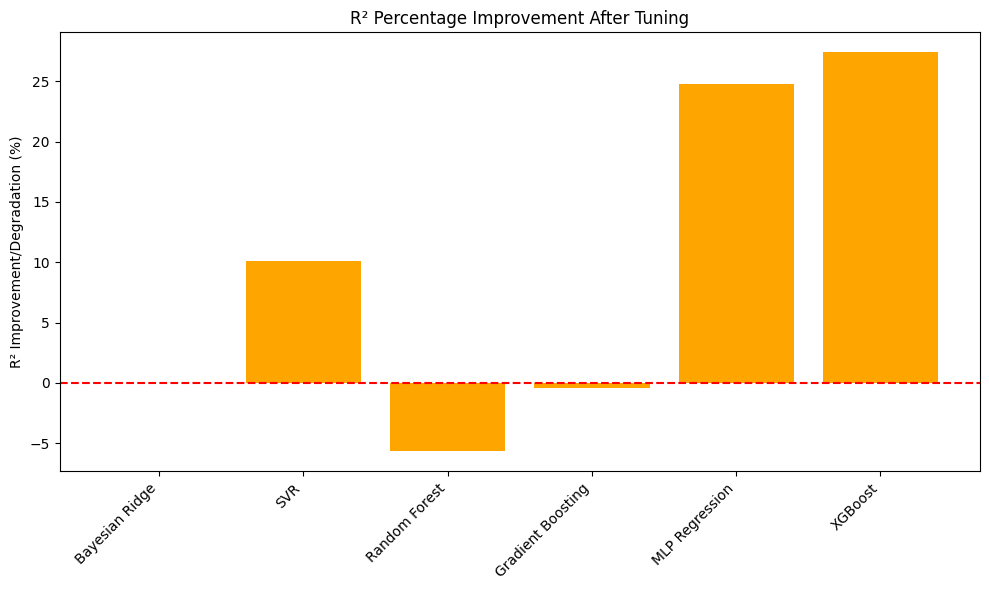

In [137]:
# Function to calculate percentage change for improvement (positive) or degradation (negative)
def calculate_percentage_change(base_value, tuned_value, reverse=False):
    if reverse:
        return ((tuned_value - base_value) / base_value) * 100  # For R² where higher is better
    else:
        return ((base_value - tuned_value) / base_value) * 100  # For MSE, MAE where lower is better

# Base and tuned model pairs
base_and_tuned_pairs = [
    ('Bayesian Ridge', 'Bayesian Ridge Tuned'),
    ('SVR', 'SVR Tuned'),
    ('Random Forest', 'Random Forest Tuned'),
    ('Gradient Boosting', 'Gradient Boosting Tuned'),
    ('MLP Regression', 'MLP Regression Tuned'),
    ('XGBoost', 'XGBoost Tuned')
]

# Extract base and tuned pairs and calculate performance improvement/degradation for MSE, MAE, R2
improvement_data = []

for base_model, tuned_model in base_and_tuned_pairs:
    # Extract MSE, MAE, R² for base and tuned models
    base_mse = metrics_df.loc[metrics_df['Model'] == base_model, 'MSE'].values[0]
    tuned_mse = metrics_df.loc[metrics_df['Model'] == tuned_model, 'MSE'].values[0]
    
    base_mae = metrics_df.loc[metrics_df['Model'] == base_model, 'MAE'].values[0]
    tuned_mae = metrics_df.loc[metrics_df['Model'] == tuned_model, 'MAE'].values[0]
    
    base_r2 = metrics_df.loc[metrics_df['Model'] == base_model, 'R2'].values[0]
    tuned_r2 = metrics_df.loc[metrics_df['Model'] == tuned_model, 'R2'].values[0]

    # Calculate percentage changes for MSE, MAE, and R² (MSE and MAE: lower is better; R²: higher is better)
    mse_change = calculate_percentage_change(base_mse, tuned_mse)
    mae_change = calculate_percentage_change(base_mae, tuned_mae)
    r2_change = calculate_percentage_change(base_r2, tuned_r2, reverse=True)
    
    # Aggregate the improvement data
    improvement_data.append((base_model, mse_change, mae_change, r2_change))

# Convert to DataFrame for easier plotting/printing
improvement_df = pd.DataFrame(improvement_data, columns=['Model', 'MSE Improvement (%)', 'MAE Improvement (%)', 'R2 Improvement (%)'])

# Print the percentage improvement or degradation for MSE, MAE, and R²
print(improvement_df)

# Plot the percentage improvement/degradation for each metric

# MSE Improvement
plt.figure(figsize=(10, 6))
plt.bar(improvement_df['Model'], improvement_df['MSE Improvement (%)'], color='skyblue')
plt.axhline(0, color='red', linestyle='--')  # Add a line for 0% change
plt.xticks(rotation=45, ha='right')
plt.ylabel('MSE Improvement/Degradation (%)')
plt.title('MSE Percentage Improvement After Tuning')
plt.tight_layout()
plt.show()

# MAE Improvement
plt.figure(figsize=(10, 6))
plt.bar(improvement_df['Model'], improvement_df['MAE Improvement (%)'], color='lightgreen')
plt.axhline(0, color='red', linestyle='--')  # Add a line for 0% change
plt.xticks(rotation=45, ha='right')
plt.ylabel('MAE Improvement/Degradation (%)')
plt.title('MAE Percentage Improvement After Tuning')
plt.tight_layout()
plt.show()

# R² Improvement
plt.figure(figsize=(10, 6))
plt.bar(improvement_df['Model'], improvement_df['R2 Improvement (%)'], color='orange')
plt.axhline(0, color='red', linestyle='--')  # Add a line for 0% change
plt.xticks(rotation=45, ha='right')
plt.ylabel('R² Improvement/Degradation (%)')
plt.title('R² Percentage Improvement After Tuning')
plt.tight_layout()
plt.show()

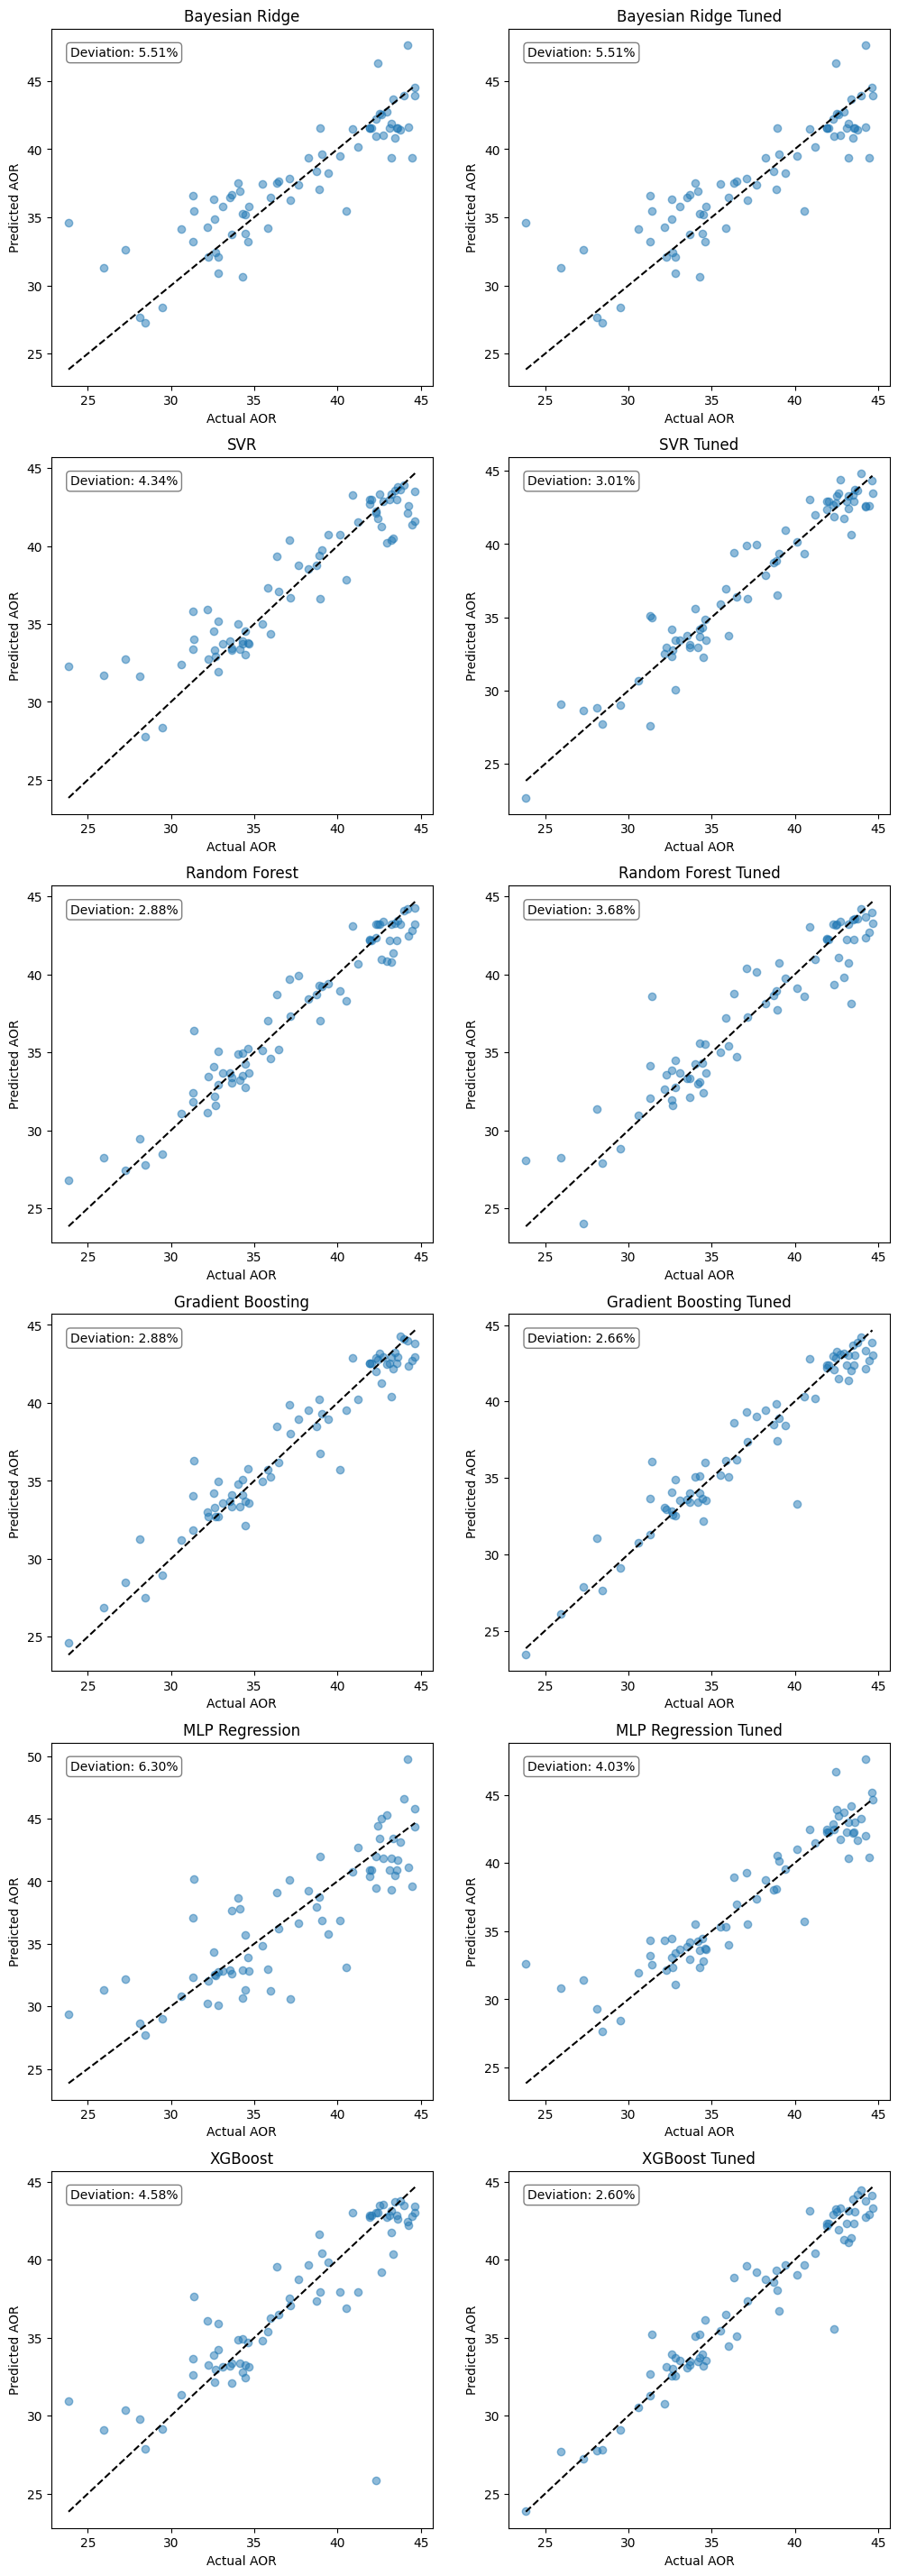

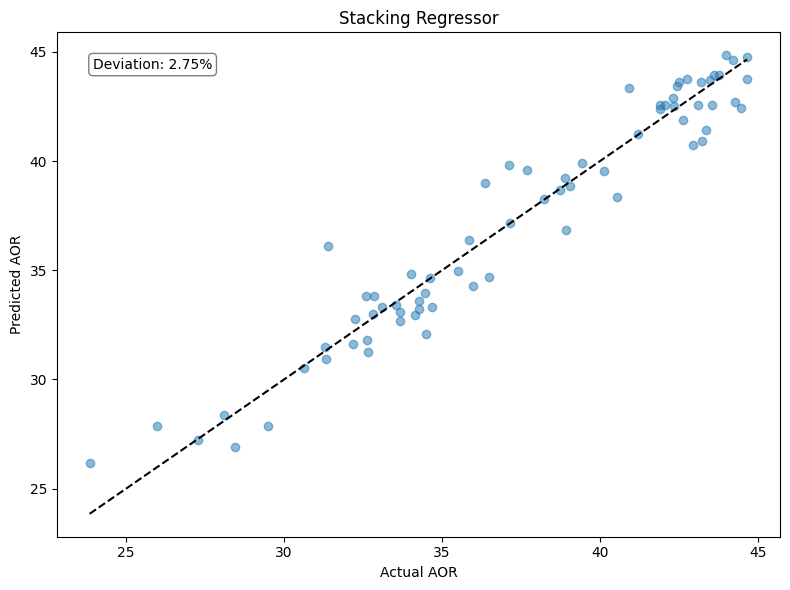

In [19]:
# Plot Actual vs Predicted for Each Model


# Function to calculate deviation percentage
def calculate_deviation(y_true, y_pred):
    deviation = np.abs((y_pred - y_true) / y_true) * 100
    avg_deviation = np.mean(deviation)  # Average deviation percentage
    return avg_deviation

# Group base and tuned models
base_and_tuned_pairs = [
    ('Bayesian Ridge', 'Bayesian Ridge Tuned'),
    ('SVR', 'SVR Tuned'),
    ('Random Forest', 'Random Forest Tuned'),
    ('Gradient Boosting', 'Gradient Boosting Tuned'),
    ('MLP Regression', 'MLP Regression Tuned'),
    ('XGBoost', 'XGBoost Tuned')
]

# Define columns and rows for subplot grid
cols = 2
rows = len(base_and_tuned_pairs)

# Create subplots for base and tuned models (2 columns per pair)
fig, axes = plt.subplots(rows, cols, figsize=(12, 6 * rows))
axes = axes.flatten()

# Plot base and tuned models side by side, with deviation displayed
for idx, (base_model, tuned_model) in enumerate(base_and_tuned_pairs):
    # Base model plot
    ax_base = axes[idx * 2]
    y_pred_base = results[base_model]['y_pred']
    deviation_base = calculate_deviation(y_test, y_pred_base)
    
    ax_base.scatter(y_test, y_pred_base, alpha=0.5)
    ax_base.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
    ax_base.set_title(f'{base_model}')
    ax_base.set_xlabel('Actual AOR')
    ax_base.set_ylabel('Predicted AOR')
    ax_base.text(0.05, 0.95, f'Deviation: {deviation_base:.2f}%',
                 transform=ax_base.transAxes, fontsize=10, verticalalignment='top',
                 bbox=dict(boxstyle='round,pad=0.3', edgecolor='gray', facecolor='white'))

    # Tuned model plot
    ax_tuned = axes[idx * 2 + 1]
    y_pred_tuned = results[tuned_model]['y_pred']
    deviation_tuned = calculate_deviation(y_test, y_pred_tuned)
    
    ax_tuned.scatter(y_test, y_pred_tuned, alpha=0.5)
    ax_tuned.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
    ax_tuned.set_title(f'{tuned_model}')
    ax_tuned.set_xlabel('Actual AOR')
    ax_tuned.set_ylabel('Predicted AOR')
    ax_tuned.text(0.05, 0.95, f'Deviation: {deviation_tuned:.2f}%',
                  transform=ax_tuned.transAxes, fontsize=10, verticalalignment='top',
                  bbox=dict(boxstyle='round,pad=0.3', edgecolor='gray', facecolor='white'))

# Plot Stacking Regressor separately
fig_stacking, ax_stacking = plt.subplots(figsize=(8, 6))
y_pred_stacking = results['Stacking Regressor']['y_pred']
deviation_stacking = calculate_deviation(y_test, y_pred_stacking)

ax_stacking.scatter(y_test, y_pred_stacking, alpha=0.5)
ax_stacking.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
ax_stacking.set_title('Stacking Regressor')
ax_stacking.set_xlabel('Actual AOR')
ax_stacking.set_ylabel('Predicted AOR')
ax_stacking.text(0.05, 0.95, f'Deviation: {deviation_stacking:.2f}%',
                 transform=ax_stacking.transAxes, fontsize=10, verticalalignment='top',
                 bbox=dict(boxstyle='round,pad=0.3', edgecolor='gray', facecolor='white'))

# Show both plots
plt.tight_layout()
plt.show()

In [22]:
# Sort models by R2 Score
best_model = metrics_df.sort_values(by='R2', ascending=False).iloc[0]
print(f"The best model is {best_model['Model']} with an R2 score of {best_model['R2']:.4f}")

The best model is Stacking Regressor with an R2 score of 0.9376


Best model: XGBoost Tuned with 2.60% deviation


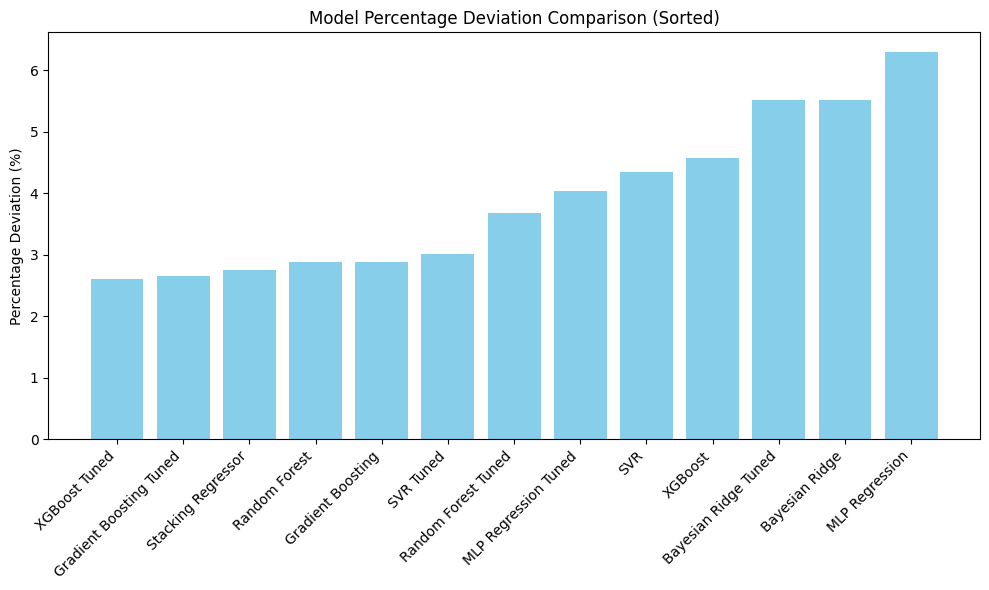

In [134]:
# def compute_percentage_error(y_true, y_pred):
#     percentage_errors = np.abs((y_true - y_pred) / y_true) * 100
#     mean_percentage_error = np.mean(percentage_errors)
#     print(f'Mean Percentage Error: {mean_percentage_error:.2f}%')
#     return mean_percentage_error

# # For the best model (assuming Random Forest performed best)
# print('Deviation for Random Forest Regression:')
# mean_pct_error_rf = compute_percentage_error(y_test, results['Random Forest Tuned']['y_pred'])

# print('Deviation for SVR:')
# mean_pct_error_svr = compute_percentage_error(y_test, results['SVR Tuned']['y_pred'])

# print('Deviation for Bayesian Ridge Regression:')
# mean_pct_error_bayesian = compute_percentage_error(y_test, results['Bayesian Ridge Tuned']['y_pred'])

# print('Deviation for Stacking Regressor:')
# mean_pct_error_bayesian = compute_percentage_error(y_test, results['Stacking Regressor']['y_pred'])
# Calculate percentage deviation function
def calculate_deviation(y_true, y_pred):
    deviation = np.abs((y_pred - y_true) / y_true) * 100
    avg_deviation = np.mean(deviation)  # Average deviation percentage
    return avg_deviation

# Convert results dictionary to DataFrame for easier handling
metrics_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})

# Apply the deviation calculation to each row and add it as a new column 'Deviation'
metrics_df['Deviation'] = metrics_df.apply(lambda row: calculate_deviation(y_test, row['y_pred']), axis=1)

# Sort the DataFrame by the Deviation column
metrics_df_sorted = metrics_df.sort_values(by='Deviation')

# Find the best model based on deviation
best_model = metrics_df_sorted.iloc[0]  # First row of the sorted DataFrame
print(f"Best model: {best_model['Model']} with {best_model['Deviation']:.2f}% deviation")

# Plot the deviation percentages for each model (sorted)
plt.figure(figsize=(10, 6))
plt.bar(metrics_df_sorted['Model'], metrics_df_sorted['Deviation'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Percentage Deviation (%)')
plt.title('Model Percentage Deviation Comparison (Sorted)')
plt.tight_layout()
plt.show()

In [138]:
scaler = MinMaxScaler()
scaler.fit_transform(X_train)

manual_input = pd.DataFrame(np.array([[0.6, 2.50E-06, 0.75, 0.4, 2.25E-07, 0.4, 0.25]]), columns=X_train.columns)
# manual_input = pd.DataFrame(np.array([[0.7, 0.01, 0.4, 0.0001, -0.00000284, 0.7, 1.0]]), columns=X_train.columns)
# manual_input = pd.DataFrame(np.array([[0.3, 4.00E-05, 0.4, 0.32, 2.00E-07, 0.3, 0.7]]), columns=X_train.columns)
scaled_input = scaler.transform(manual_input)

prediction = results['XGBoost Tuned']['model'].predict(scaled_input)

print(f"Prediction for scaled manual input: {prediction}")

Prediction for scaled manual input: [27.83616]
